# CIFAR-10: аугментация данных

**Аугментация** — это когда мы на лету портим картинки обучающей выборки:
сдвигаем, отражаем, меняем яркость. Сеть каждую эпоху видит чуть другой
вариант одной и той же картинки и поэтому хуже её запоминает наизусть.

CIFAR-10: **60 000 цветных картинок 32x32**, **10 классов**
(самолёт, машина, птица, кот, олень, собака, лягушка, лошадь, корабль, грузовик).

Что делаем:
1. смотрим, как каждое преобразование меняет картинку
2. обучаем одну и ту же сеть **без аугментации** и **с аугментацией**
3. сравниваем кривые обучения — видим, как уходит переобучение

## 1. Импорты

In [47]:
%matplotlib inline
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# mps - видеокарта на маке, cuda - на nvidia, cpu - если ничего нет
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('torch      :', torch.__version__)
print('устройство :', device)

torch      : 2.13.0
устройство : mps


## 2. Загружаем CIFAR-10

Датасет скачается в папку `data/` рядом с остальными (MNIST, FashionMNIST, gtsrb).
Первый раз качается ~170 МБ, дальше берётся с диска.

In [48]:
DATA_DIR = '../../../data'

CLASSES = ['самолёт', 'машина', 'птица', 'кот', 'олень',
           'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# raw - без преобразований, картинки остаются PIL. Нужен, чтобы показывать примеры.
raw_train = datasets.CIFAR10(DATA_DIR, train=True,  download=True)
raw_test  = datasets.CIFAR10(DATA_DIR, train=False, download=True)

print('train:', len(raw_train))
print('test :', len(raw_test))
print('размер картинки:', raw_train[0][0].size, '- очень маленькая, 32x32')

train: 50000
test : 10000
размер картинки: (32, 32) - очень маленькая, 32x32


### Как выглядят данные

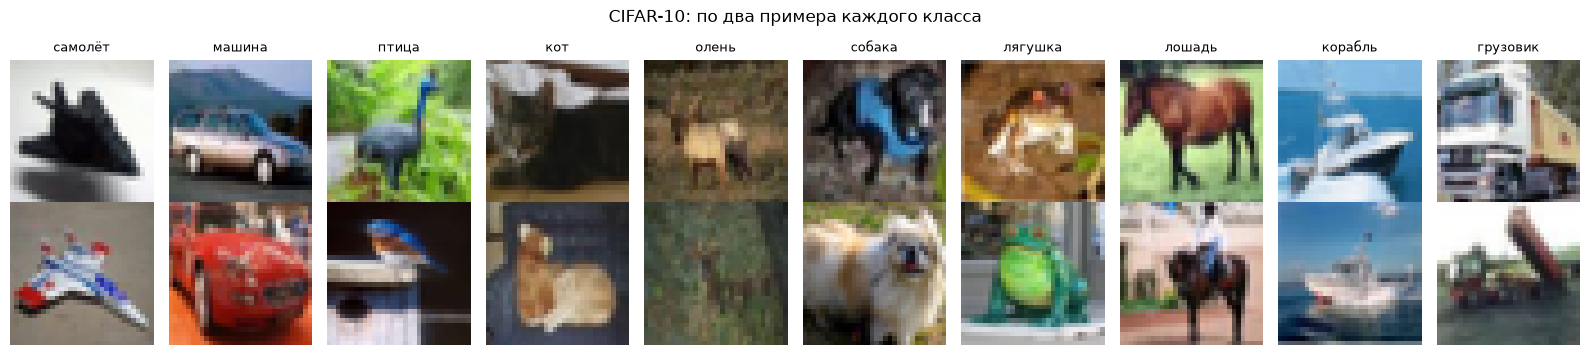

In [49]:
fig, axes = plt.subplots(2, 10, figsize=(16, 3.6))
for cls in range(10):
    # находим первые две картинки каждого класса
    found = [i for i in range(2000) if raw_train.targets[i] == cls][:2]
    for row, i in enumerate(found):
        axes[row, cls].imshow(raw_train[i][0])
        axes[row, cls].axis('off')
    axes[0, cls].set_title(CLASSES[cls], fontsize=9)

plt.suptitle('CIFAR-10: по два примера каждого класса')
plt.tight_layout()
plt.show()

## 3. Смотрим, что делает каждое преобразование

Возьмём одну картинку и прогоним через разные аугментации.
Преобразование случайное, поэтому каждый раз результат немного другой.

класс: лошадь


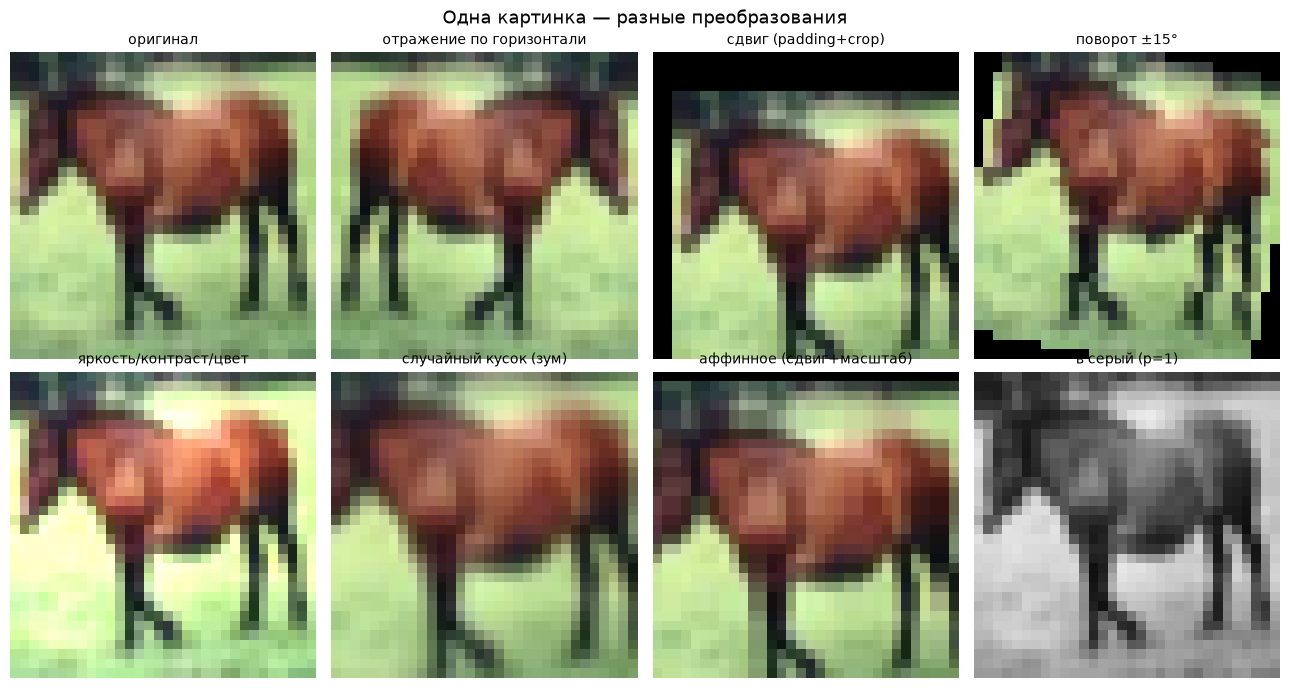

In [50]:
SAMPLE = 7                      # поменяй индекс, чтобы взять другую картинку
img, label = raw_train[SAMPLE]
print('класс:', CLASSES[label])

# Словарь: название -> преобразование. Все работают с PIL-картинкой.
augmentations = {
    'оригинал':            transforms.Compose([]),
    'отражение по горизонтали': transforms.RandomHorizontalFlip(p=1.0),
    'сдвиг (padding+crop)':     transforms.RandomCrop(32, padding=4),
    'поворот ±15°':             transforms.RandomRotation(15),
    'яркость/контраст/цвет':    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    'случайный кусок (зум)':    transforms.RandomResizedCrop(32, scale=(0.6, 1.0)),
    'аффинное (сдвиг+масштаб)': transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    'в серый (p=1)':            transforms.Grayscale(num_output_channels=3),
}

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, (name, tf_) in zip(axes.ravel(), augmentations.items()):
    ax.imshow(tf_(img))
    ax.set_title(name, fontsize=10)
    ax.axis('off')

plt.suptitle('Одна картинка — разные преобразования', fontsize=13)
plt.tight_layout()
plt.show()

### Одно преобразование — много случайных результатов

`RandomCrop(32, padding=4)` сначала добавляет по 4 пикселя с каждой стороны
(получается 40x40), а потом вырезает случайный кусок 32x32.
Сдвиг получается разный каждый раз.

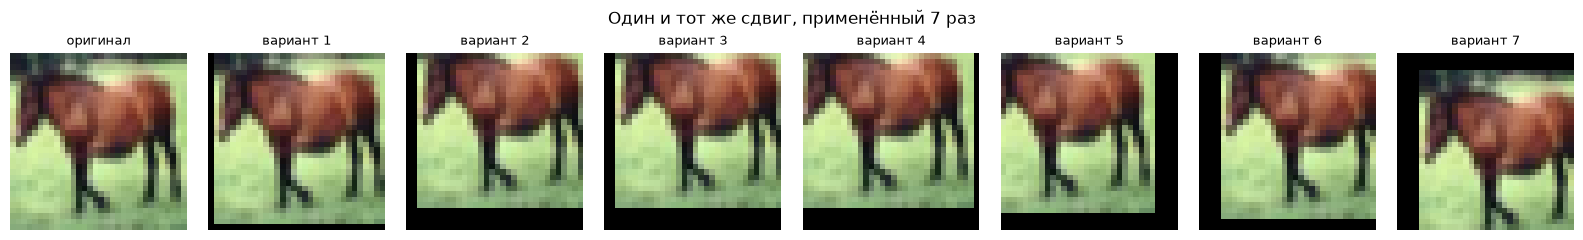

In [51]:
shift = transforms.RandomCrop(32, padding=4)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
for i, ax in enumerate(axes):
    ax.imshow(img if i == 0 else shift(img))
    ax.set_title('оригинал' if i == 0 else 'вариант %d' % i, fontsize=9)
    ax.axis('off')
plt.suptitle('Один и тот же сдвиг, применённый 7 раз')
plt.tight_layout()
plt.show()

### ⚠️ Аугментация должна оставлять класс прежним

Отражение по вертикали для CIFAR-10 — **плохая идея**: перевёрнутая вверх ногами
лошадь в реальных данных не встречается, сеть будет учиться на том, чего нет.
Сильный поворот — тоже сомнительно.

Правило: если человек после преобразования всё ещё назовёт тот же класс
и такая картинка могла бы встретиться в жизни — преобразование подходит.

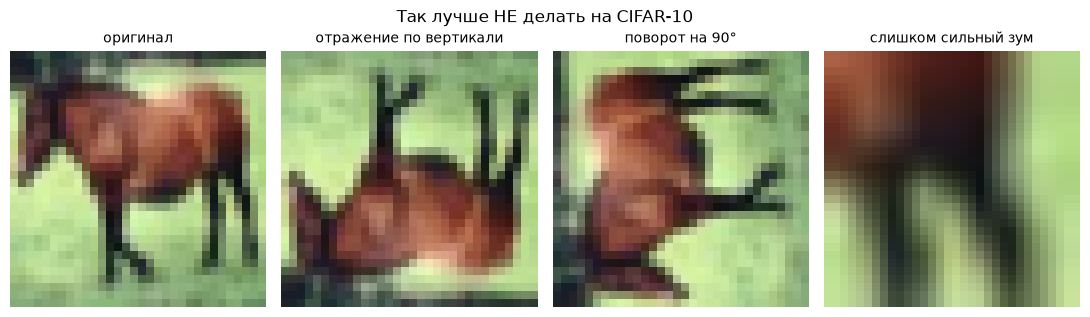

In [52]:
bad = {
    'оригинал':                 transforms.Compose([]),
    'отражение по вертикали':   transforms.RandomVerticalFlip(p=1.0),
    'поворот на 90°':           transforms.RandomRotation((90, 90)),
    'слишком сильный зум':      transforms.RandomResizedCrop(32, scale=(0.1, 0.15)),
}

fig, axes = plt.subplots(1, 4, figsize=(11, 3.2))
for ax, (name, tf_) in zip(axes, bad.items()):
    ax.imshow(tf_(img))
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.suptitle('Так лучше НЕ делать на CIFAR-10', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Собираем два набора преобразований

**Важно:** аугментация применяется **только к train**.
Тест должен оставаться честным — там только приведение к тензору и нормализация.

`Normalize` вычитает среднее и делит на стандартное отклонение по каждому
из трёх каналов. Числа ниже — известные статистики CIFAR-10.

In [53]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

# без аугментации
plain_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# с аугментацией
augment_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),          # случайный сдвиг
    transforms.RandomHorizontalFlip(),             # отражение, p=0.5 по умолчанию
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),   # стирает случайный прямоугольник
])

print('порядок важен: RandomErasing работает уже с тензором, поэтому стоит после ToTensor()')

порядок важен: RandomErasing работает уже с тензором, поэтому стоит после ToTensor()


### Что видит сеть на входе

Одна и та же картинка, пропущенная через `augment_tf` несколько раз.
Нормализацию для показа откатываем обратно, иначе цвета будут сломаны.

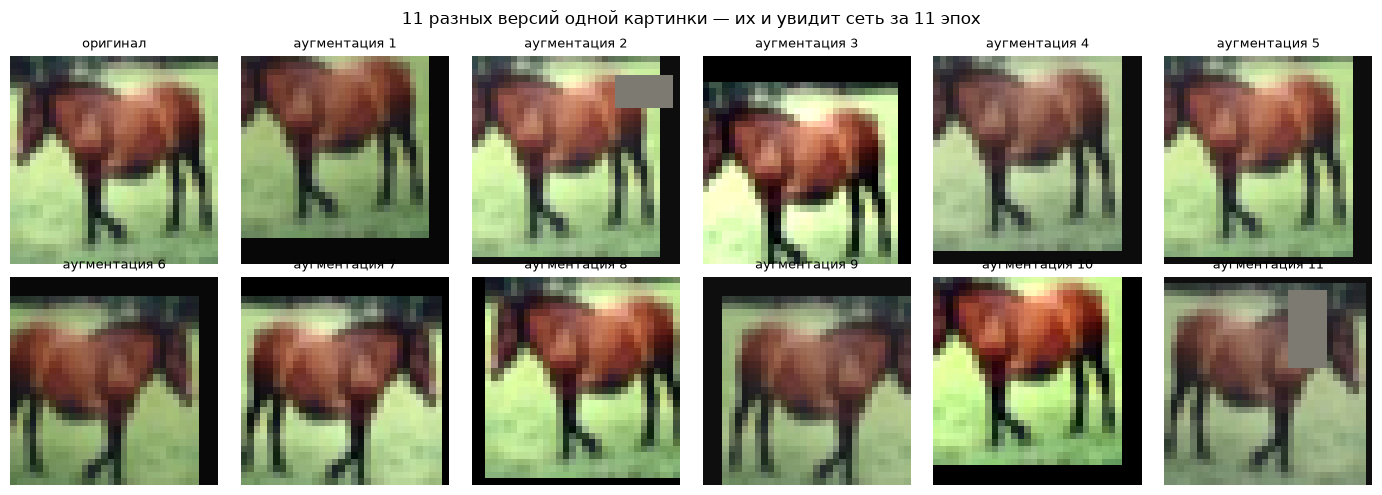

In [54]:
def denormalize(t):
    """Возвращает тензор из нормализованного вида в диапазон 0..1 для показа."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes[0, 0].imshow(img)
axes[0, 0].set_title('оригинал', fontsize=9)
axes[0, 0].axis('off')

for k, ax in enumerate(axes.ravel()[1:]):
    ax.imshow(denormalize(augment_tf(img)))
    ax.set_title('аугментация %d' % (k + 1), fontsize=9)
    ax.axis('off')

plt.suptitle('11 разных версий одной картинки — их и увидит сеть за 11 эпох')
plt.tight_layout()
plt.show()

## 5. Датасеты и загрузчики

Делаем два train-датасета поверх одних и тех же файлов — отличаются только
преобразованием. Тестовый набор общий.

In [55]:
BATCH_SIZE = 128

train_plain = datasets.CIFAR10(DATA_DIR, train=True,  transform=plain_tf)
train_aug   = datasets.CIFAR10(DATA_DIR, train=True,  transform=augment_tf)
test_set    = datasets.CIFAR10(DATA_DIR, train=False, transform=plain_tf)

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

loader_plain = make_loader(train_plain, True)
loader_aug   = make_loader(train_aug,   True)
loader_test  = make_loader(test_set,    False)

xb, yb = next(iter(loader_aug))
print('форма батча:', xb.shape, '- (картинок, каналов, высота, ширина)')
print('меток       :', yb.shape)

форма батча: torch.Size([128, 3, 32, 32]) - (картинок, каналов, высота, ширина)
меток       : torch.Size([128])


## 6. Сеть

Обычная небольшая свёрточная сеть: три блока «свёртка -> нормализация ->
ReLU -> свёртка -> ... -> пулинг». Она одинаковая в обоих экспериментах,
меняются **только данные**.

In [56]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),                    # уменьшает картинку вдвое
    )


class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),              # 32x32 -> 16x16
            conv_block(32, 64),             # 16x16 -> 8x8
            conv_block(64, 128),            # 8x8   -> 4x4
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


print(SmallCNN())
print()
print('параметров:', sum(p.numel() for p in SmallCNN().parameters()))

SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=T

## 7. Функции обучения

In [57]:
@torch.no_grad()
def evaluate(model, loader):
    """Считает средний loss и точность на переданном загрузчике."""
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss_sum += F.cross_entropy(out, yb, reduction='sum').item()
        correct  += (out.argmax(1) == yb).sum().item()
        total    += yb.size(0)
    return loss_sum / total, correct / total


def train(loader, epochs=15, title=''):
    """Обучает свежую сеть на loader, каждую эпоху меряет train и test."""
    torch.manual_seed(SEED)                       # одинаковый старт у обоих запусков
    model = SmallCNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    t0 = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = F.cross_entropy(out, yb)
            loss.backward()
            opt.step()

            loss_sum += loss.item() * yb.size(0)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += yb.size(0)

        te_loss, te_acc = evaluate(model, loader_test)
        history['train_loss'].append(loss_sum / total)
        history['train_acc'].append(correct / total)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        print('%s эпоха %2d/%d | train acc %.4f | test acc %.4f' %
              (title, ep, epochs, correct / total, te_acc))

    print('%s готово за %.1f сек, лучшая test acc: %.4f' %
          (title, time.time() - t0, max(history['test_acc'])))
    return model, history

## 8. Эксперимент 1 — без аугментации

Одна эпоха занимает ~11 секунд на видеокарте мака, 30 эпох — около 6 минут
на каждый эксперимент. Уменьши `EPOCHS`, если ждать долго.

In [58]:
EPOCHS = 30

model_plain, hist_plain = train(loader_plain, EPOCHS, title='[без аугм.]')

[без аугм.] эпоха  1/30 | train acc 0.5654 | test acc 0.6040
[без аугм.] эпоха  2/30 | train acc 0.7401 | test acc 0.7549
[без аугм.] эпоха  3/30 | train acc 0.7990 | test acc 0.7702
[без аугм.] эпоха  4/30 | train acc 0.8343 | test acc 0.7765
[без аугм.] эпоха  5/30 | train acc 0.8625 | test acc 0.7682
[без аугм.] эпоха  6/30 | train acc 0.8851 | test acc 0.8213
[без аугм.] эпоха  7/30 | train acc 0.9039 | test acc 0.8098
[без аугм.] эпоха  8/30 | train acc 0.9236 | test acc 0.8193
[без аугм.] эпоха  9/30 | train acc 0.9375 | test acc 0.8040
[без аугм.] эпоха 10/30 | train acc 0.9500 | test acc 0.8235
[без аугм.] эпоха 11/30 | train acc 0.9612 | test acc 0.8244
[без аугм.] эпоха 12/30 | train acc 0.9688 | test acc 0.8166
[без аугм.] эпоха 13/30 | train acc 0.9709 | test acc 0.8184
[без аугм.] эпоха 14/30 | train acc 0.9767 | test acc 0.8259
[без аугм.] эпоха 15/30 | train acc 0.9757 | test acc 0.8179
[без аугм.] эпоха 16/30 | train acc 0.9781 | test acc 0.8224
[без аугм.] эпоха 17/30 

## 9. Эксперимент 2 — с аугментацией

In [59]:
model_aug, hist_aug = train(loader_aug, EPOCHS, title='[с аугм.]  ')

[с аугм.]   эпоха  1/30 | train acc 0.4634 | test acc 0.6160
[с аугм.]   эпоха  2/30 | train acc 0.6506 | test acc 0.6772
[с аугм.]   эпоха  3/30 | train acc 0.7137 | test acc 0.7040
[с аугм.]   эпоха  4/30 | train acc 0.7487 | test acc 0.7359
[с аугм.]   эпоха  5/30 | train acc 0.7744 | test acc 0.7455
[с аугм.]   эпоха  6/30 | train acc 0.7919 | test acc 0.7782
[с аугм.]   эпоха  7/30 | train acc 0.8031 | test acc 0.7989
[с аугм.]   эпоха  8/30 | train acc 0.8160 | test acc 0.7790
[с аугм.]   эпоха  9/30 | train acc 0.8250 | test acc 0.8350
[с аугм.]   эпоха 10/30 | train acc 0.8311 | test acc 0.8215
[с аугм.]   эпоха 11/30 | train acc 0.8390 | test acc 0.7955
[с аугм.]   эпоха 12/30 | train acc 0.8437 | test acc 0.8217
[с аугм.]   эпоха 13/30 | train acc 0.8524 | test acc 0.8509
[с аугм.]   эпоха 14/30 | train acc 0.8582 | test acc 0.8142
[с аугм.]   эпоха 15/30 | train acc 0.8622 | test acc 0.8237
[с аугм.]   эпоха 16/30 | train acc 0.8647 | test acc 0.8557
[с аугм.]   эпоха 17/30 

## 10. Сравниваем

На что смотреть:

- **разрыв между train и test** — без аугментации train-точность уезжает
  к единице, а test стоит на месте. Это и есть переобучение.
- **test loss** без аугментации в какой-то момент начинает **расти**,
  хотя точность ещё держится — сеть становится всё увереннее в своих ошибках.
- с аугментацией сеть учится медленнее, но итоговая test-точность выше.

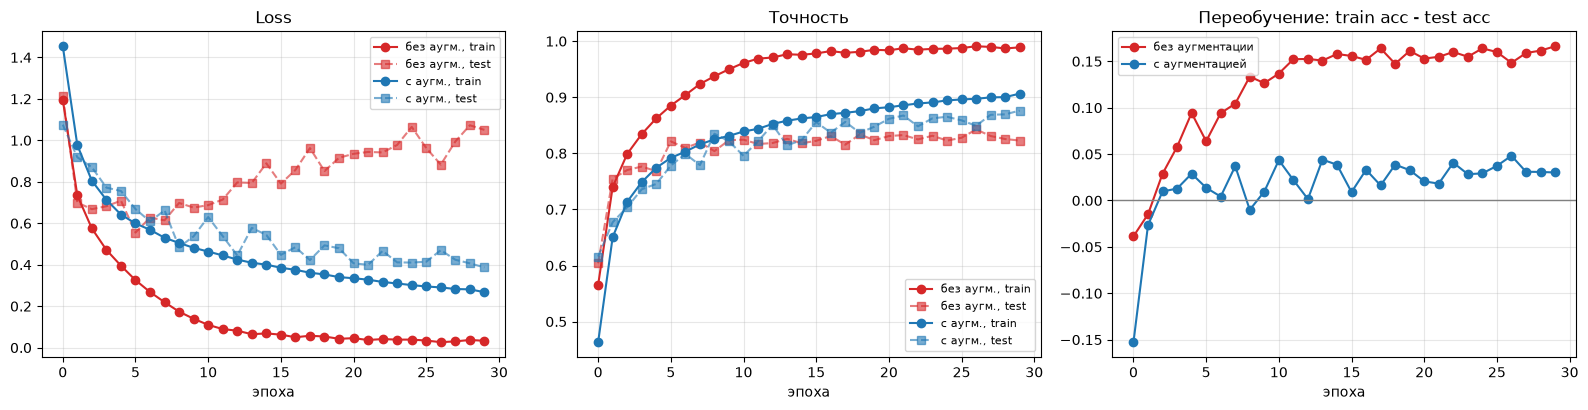

лучшая test acc без аугментации: 0.8426  (84.26%)
лучшая test acc с аугментацией : 0.8763  (87.63%)
разница: +3.37 процентных пункта


In [60]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

ax[0].plot(hist_plain['train_loss'], 'o-',  color='tab:red',  label='без аугм., train')
ax[0].plot(hist_plain['test_loss'],  's--', color='tab:red',  label='без аугм., test', alpha=0.6)
ax[0].plot(hist_aug['train_loss'],   'o-',  color='tab:blue', label='с аугм., train')
ax[0].plot(hist_aug['test_loss'],    's--', color='tab:blue', label='с аугм., test', alpha=0.6)
ax[0].set_title('Loss')
ax[0].set_xlabel('эпоха')
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

ax[1].plot(hist_plain['train_acc'], 'o-',  color='tab:red',  label='без аугм., train')
ax[1].plot(hist_plain['test_acc'],  's--', color='tab:red',  label='без аугм., test', alpha=0.6)
ax[1].plot(hist_aug['train_acc'],   'o-',  color='tab:blue', label='с аугм., train')
ax[1].plot(hist_aug['test_acc'],    's--', color='tab:blue', label='с аугм., test', alpha=0.6)
ax[1].set_title('Точность')
ax[1].set_xlabel('эпоха')
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)

gap_plain = np.array(hist_plain['train_acc']) - np.array(hist_plain['test_acc'])
gap_aug   = np.array(hist_aug['train_acc'])   - np.array(hist_aug['test_acc'])
ax[2].plot(gap_plain, 'o-', color='tab:red',  label='без аугментации')
ax[2].plot(gap_aug,   'o-', color='tab:blue', label='с аугментацией')
ax[2].axhline(0, color='gray', lw=1)
ax[2].set_title('Переобучение: train acc - test acc')
ax[2].set_xlabel('эпоха')
ax[2].legend(fontsize=8)
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('лучшая test acc без аугментации: %.4f  (%.2f%%)' %
      (max(hist_plain['test_acc']), max(hist_plain['test_acc']) * 100))
print('лучшая test acc с аугментацией : %.4f  (%.2f%%)' %
      (max(hist_aug['test_acc']), max(hist_aug['test_acc']) * 100))
print('разница: %+.2f процентных пункта' %
      ((max(hist_aug['test_acc']) - max(hist_plain['test_acc'])) * 100))

## 11. Где модель всё ещё ошибается

Посмотрим на картинки, на которых модель с аугментацией промахнулась.
Часто это объективно сложные примеры — мелкие, размытые, в странном ракурсе.

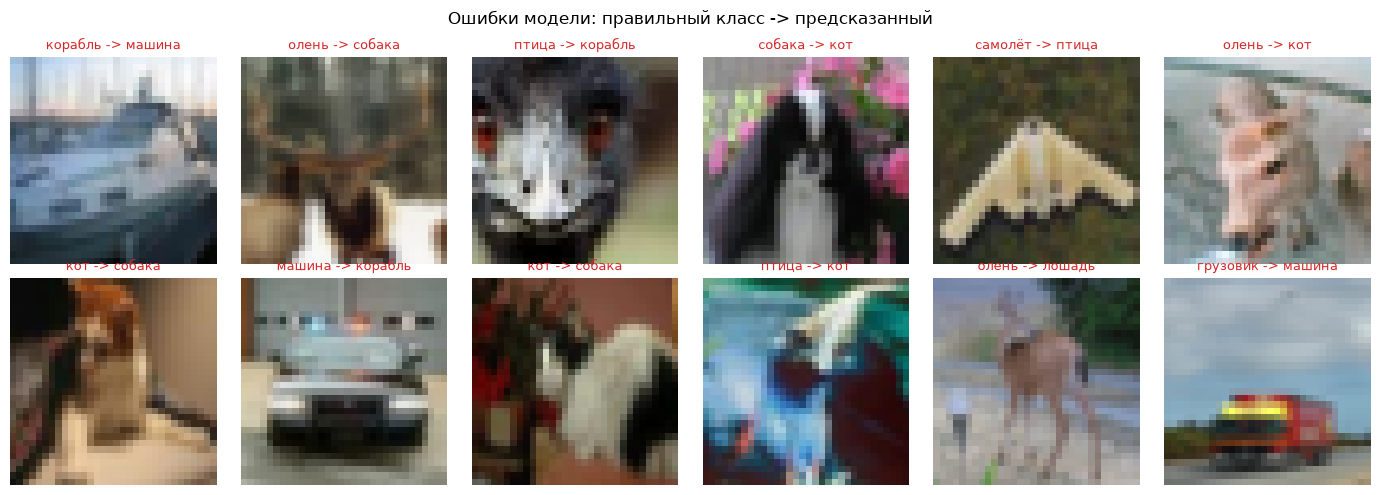

всего ошибок в тесте: 1237 из 10000  (12.37%)


In [61]:
model_aug.eval()
wrong = []

with torch.no_grad():
    for i, (xb, yb) in enumerate(loader_test):
        pred = model_aug(xb.to(device)).argmax(1).cpu()
        for j in (pred != yb).nonzero().ravel().tolist():
            wrong.append((i * BATCH_SIZE + j, yb[j].item(), pred[j].item()))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (idx, true, pred) in zip(axes.ravel(), wrong[:12]):
    ax.imshow(raw_test[idx][0])
    ax.set_title('%s -> %s' % (CLASSES[true], CLASSES[pred]), fontsize=9, color='tab:red')
    ax.axis('off')

plt.suptitle('Ошибки модели: правильный класс -> предсказанный')
plt.tight_layout()
plt.show()

print('всего ошибок в тесте: %d из %d  (%.2f%%)' %
      (len(wrong), len(test_set), 100 * len(wrong) / len(test_set)))

## 11b. Глубокая сеть: хватает ли ёмкости?

Разбор ошибок показал, что хуже всего идут **животные** — у них нет жёсткого
силуэта, зато важна текстура, а её ловят только глубокие слои. Проверим гипотезу
напрямую: добавим **четвёртый свёрточный блок** и расширим каналы.

| | SmallCNN | DeepCNN |
|---|---|---|
| свёрточных блоков | 3 | **4** |
| каналы | 32 -> 64 -> 128 | 64 -> 128 -> 256 -> **512** |
| параметров | 815 тыс. | **5.7 млн** |
| регуляризация | только аугментация | аугментация + **Dropout** |

Сеть в 7 раз больше, поэтому переобучаться она будет охотнее — добавляем
`Dropout`, который на каждом шаге случайно отключает часть нейронов
и не даёт им «сговориться».

Обучаем её **на тех же аугментированных данных**, чтобы сравнение было честным:
меняется только архитектура.

In [62]:
class DeepCNN(nn.Module):
    """Та же идея, что SmallCNN, но на один блок глубже и вдвое шире."""

    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 64),          # 32x32 -> 16x16
            conv_block(64, 128),        # 16x16 -> 8x8
            conv_block(128, 256),       # 8x8   -> 4x4
            conv_block(256, 512),       # 4x4   -> 2x2   <- четвёртый блок
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),            # гасим 30% нейронов на каждом шаге
            nn.Linear(512 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


print('SmallCNN: %9d параметров' % sum(p.numel() for p in SmallCNN().parameters()))
print('DeepCNN : %9d параметров  (в %.1f раза больше)' %
      (sum(p.numel() for p in DeepCNN().parameters()),
       sum(p.numel() for p in DeepCNN().parameters()) / sum(p.numel() for p in SmallCNN().parameters())))

SmallCNN:    815018 параметров
DeepCNN :   5743434 параметров  (в 7.0 раза больше)


Функция `train` жёстко создаёт `SmallCNN`, поэтому сделаем версию,
которой можно передать любую архитектуру.

In [63]:
def train_model(model_cls, loader, epochs=EPOCHS, title=''):
    """То же, что train, но архитектуру передаём параметром."""
    torch.manual_seed(SEED)
    model = model_cls().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    t0 = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = F.cross_entropy(out, yb)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * yb.size(0)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += yb.size(0)

        te_loss, te_acc = evaluate(model, loader_test)
        history['train_loss'].append(loss_sum / total)
        history['train_acc'].append(correct / total)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        if ep % 5 == 0 or ep == 1:
            print('%s эпоха %2d/%d | train acc %.4f | test acc %.4f' %
                  (title, ep, epochs, correct / total, te_acc))

    print('%s готово за %.1f мин, лучшая test acc: %.4f' %
          (title, (time.time() - t0) / 60, max(history['test_acc'])))
    return model, history


model_deep, hist_deep = train_model(DeepCNN, loader_aug, EPOCHS, title='[глубокая]')

[глубокая] эпоха  1/30 | train acc 0.3447 | test acc 0.5340
[глубокая] эпоха  5/30 | train acc 0.7623 | test acc 0.7914
[глубокая] эпоха 10/30 | train acc 0.8444 | test acc 0.8324
[глубокая] эпоха 15/30 | train acc 0.8826 | test acc 0.8485
[глубокая] эпоха 20/30 | train acc 0.9097 | test acc 0.8876
[глубокая] эпоха 25/30 | train acc 0.9257 | test acc 0.8984
[глубокая] эпоха 30/30 | train acc 0.9386 | test acc 0.9047
[глубокая] готово за 99.8 мин, лучшая test acc: 0.9047


### Три кривые рядом

Теперь у нас три эксперимента: мелкая сеть без аугментации, мелкая с аугментацией
и глубокая с аугментацией.

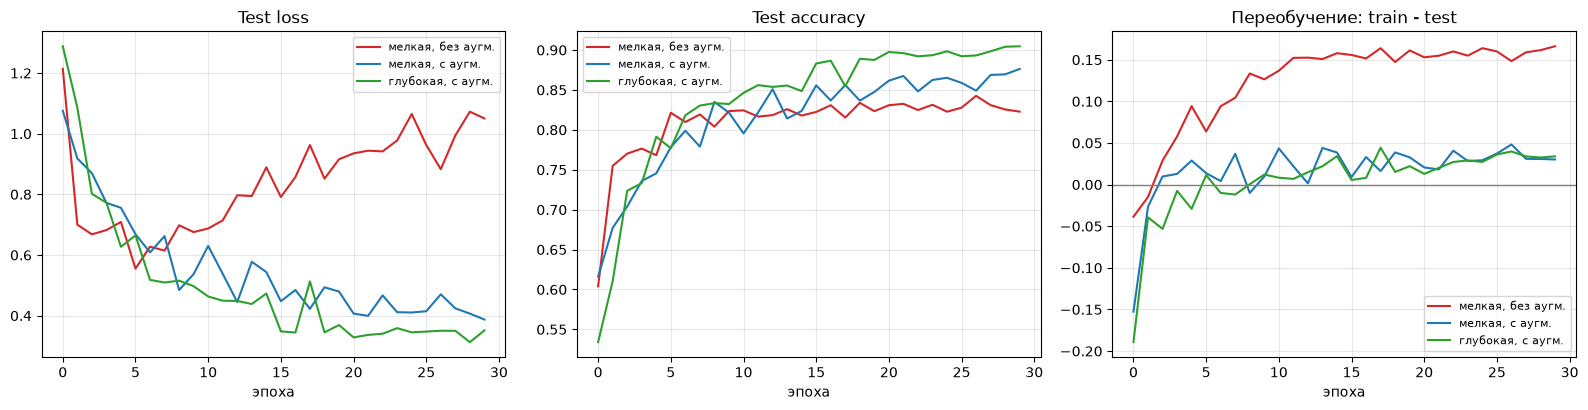

эксперимент                test acc       разрыв
мелкая, без аугм.            0.8426        0.166
мелкая, с аугм.              0.8763        0.030
глубокая, с аугм.            0.9047        0.034


In [64]:
runs = [
    ('мелкая, без аугм.', hist_plain, 'tab:red'),
    ('мелкая, с аугм.',   hist_aug,   'tab:blue'),
    ('глубокая, с аугм.', hist_deep,  'tab:green'),
]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for name, h, c in runs:
    ax[0].plot(h['test_loss'], color=c, label=name)
    ax[1].plot(h['test_acc'],  color=c, label=name)
    ax[2].plot(np.array(h['train_acc']) - np.array(h['test_acc']), color=c, label=name)

ax[0].set_title('Test loss');                     ax[0].set_xlabel('эпоха')
ax[1].set_title('Test accuracy');                 ax[1].set_xlabel('эпоха')
ax[2].set_title('Переобучение: train - test');    ax[2].set_xlabel('эпоха')
ax[2].axhline(0, color='gray', lw=1)
for a in ax:
    a.legend(fontsize=8)
    a.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('%-22s %12s %12s' % ('эксперимент', 'test acc', 'разрыв'))
for name, h, _ in runs:
    best = max(h['test_acc'])
    gap = h['train_acc'][-1] - h['test_acc'][-1]
    print('%-22s %12.4f %12.3f' % (name, best, gap))

### Что дала глубина по классам

Главный вопрос: подтянулись ли именно **животные**, как мы и предполагали?
Считаем точность классификации по каждому классу для всех трёх моделей.

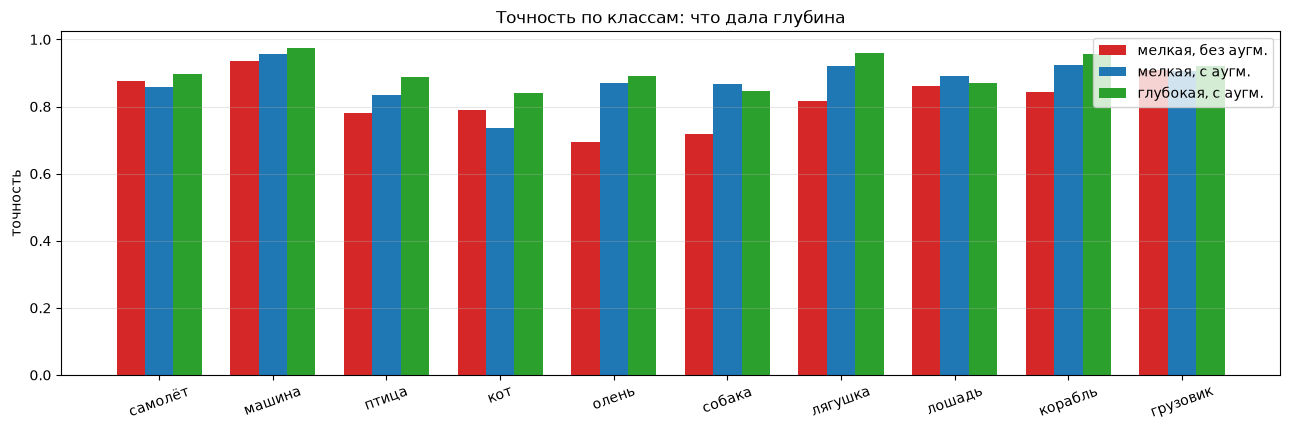

класс         без аугм.    с аугм.   глубокая  глуб.-мелк.
самолёт           0.877      0.858      0.898       +0.040
машина            0.936      0.957      0.975       +0.018
птица             0.781      0.835      0.889       +0.054  (животное)
кот               0.790      0.735      0.841       +0.106  (животное)
олень             0.695      0.870      0.892       +0.022  (животное)
собака            0.717      0.866      0.845       -0.021  (животное)
лягушка           0.817      0.922      0.961       +0.039  (животное)
лошадь            0.862      0.892      0.870       -0.022  (животное)
корабль           0.843      0.923      0.956       +0.033
грузовик          0.910      0.905      0.920       +0.015

животные: 0.853 -> 0.883  (+0.030)
техника : 0.911 -> 0.937  (+0.026)

разброс между классами: мелкая 0.058 -> глубокая 0.045


In [65]:
@torch.no_grad()
def per_class_accuracy(model):
    """Доля правильных ответов отдельно по каждому классу."""
    model.eval()
    correct = np.zeros(10)
    total = np.zeros(10)
    for xb, yb in loader_test:
        pred = model(xb.to(device)).argmax(1).cpu()
        for c in range(10):
            m = yb == c
            correct[c] += (pred[m] == c).sum().item()
            total[c] += m.sum().item()
    return correct / total


acc_plain = per_class_accuracy(model_plain)
acc_aug   = per_class_accuracy(model_aug)
acc_deep  = per_class_accuracy(model_deep)

ANIMALS = np.array([0, 0, 1, 1, 1, 1, 1, 1, 0, 0], dtype=bool)

x = np.arange(10)
plt.figure(figsize=(13, 4.4))
plt.bar(x - 0.25, acc_plain, 0.25, label='мелкая, без аугм.', color='tab:red')
plt.bar(x,        acc_aug,   0.25, label='мелкая, с аугм.',   color='tab:blue')
plt.bar(x + 0.25, acc_deep,  0.25, label='глубокая, с аугм.', color='tab:green')
plt.xticks(x, CLASSES, rotation=20)
plt.ylabel('точность')
plt.title('Точность по классам: что дала глубина')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('%-12s %10s %10s %10s %12s' % ('класс', 'без аугм.', 'с аугм.', 'глубокая', 'глуб.-мелк.'))
for c in range(10):
    print('%-12s %10.3f %10.3f %10.3f %+12.3f%s' %
          (CLASSES[c], acc_plain[c], acc_aug[c], acc_deep[c],
           acc_deep[c] - acc_aug[c], '  (животное)' if ANIMALS[c] else ''))

print()
print('животные: %.3f -> %.3f  (%+.3f)' %
      (acc_aug[ANIMALS].mean(), acc_deep[ANIMALS].mean(),
       acc_deep[ANIMALS].mean() - acc_aug[ANIMALS].mean()))
print('техника : %.3f -> %.3f  (%+.3f)' %
      (acc_aug[~ANIMALS].mean(), acc_deep[~ANIMALS].mean(),
       acc_deep[~ANIMALS].mean() - acc_aug[~ANIMALS].mean()))
print()
print('разброс между классами: мелкая %.3f -> глубокая %.3f' % (acc_aug.std(), acc_deep.std()))

## 12. Итоги

- Аугментация — **бесплатный способ увеличить датасет**: новых картинок не
  появляется, но сеть каждую эпоху видит их по-новому.
- Применяется **только к train**, никогда к тесту.
- Преобразование не должно менять класс: для CIFAR-10 годятся сдвиг,
  горизонтальное отражение, лёгкий цветовой джиттер; не годятся переворот
  вверх ногами и повороты на 90°.
- Аугментация замедляет обучение (train-точность растёт медленнее) — это
  нормально, зато test-точность выше и переобучение меньше.

**Что можно попробовать с аугментацией:**
- добавить `transforms.RandAugment()` или `transforms.AutoAugment()` — готовые
  наборы преобразований, подобранные перебором
- посмотреть на mixup и cutmix — там смешиваются сразу две картинки и их метки
- увеличить число эпох до 40-50: разрыв между двумя кривыми станет ещё заметнее

Дальше — вторая часть: превращаем обученную сеть в **экстрактор эмбеддингов**
и сравниваем её с EfficientNet на задаче поиска похожих картинок.

---

# Часть 2. Эмбеддинги и поиск похожих картинок

**Эмбеддинг** — это картинка, сжатая сетью в вектор чисел. Сеть, обученная
различать классы, вынуждена по пути выучить, *что вообще бывает на картинках*:
формы, текстуры, цвета. Вектор с предпоследнего слоя и есть такое описание.

Главное свойство: **похожие картинки дают близкие векторы**. Значит, чтобы
найти похожие фото, не нужен классификатор — достаточно посчитать расстояние
между векторами.

Сравним два источника эмбеддингов:

| | наша SmallCNN | EfficientNet-B0 |
|---|---|---|
| на чём обучена | CIFAR-10, 50 000 картинок 32x32 | ImageNet, 1.2 млн картинок |
| размер вектора | 256 | 1280 |
| видела ли CIFAR-10 | да, обучалась на нём | **нет, ни разу** |

Интересно как раз второе: EfficientNet никогда не видел CIFAR-10, но должен
всё равно хорошо находить похожие картинки — признаки с ImageNet переносятся
на другие данные. Это называется **transfer learning**.

## 13. Достаём эмбеддинги своей модели

Берём обученную `model_aug` и обрезаем ей последний слой. То, что раньше шло
в классификатор, теперь и есть эмбеддинг — вектор длины 256.

Напомним строение головы сети:
`Flatten -> Linear(2048, 256) -> ReLU -> Linear(256, 10)`

Нам нужен выход после `ReLU`, то есть первые три слоя головы.

In [66]:
@torch.no_grad()
def embed_smallcnn(model, loader):
    """Прогоняет все картинки через сеть и возвращает векторы с предпоследнего слоя."""
    model.eval()
    out = []
    for xb, _ in loader:
        feats = model.features(xb.to(device))      # свёрточная часть
        emb = model.head[:3](feats)                # Flatten -> Linear -> ReLU, без последнего слоя
        out.append(emb.cpu())
    return torch.cat(out)


t = time.time()
emb_own = embed_smallcnn(model_aug, loader_test)
print('эмбеддинги мелкой сети  : %s за %.1f сек' % (tuple(emb_own.shape), time.time() - t))

# у глубокой сети голова другая: Flatten -> Dropout -> Linear -> ReLU -> Dropout -> Linear
# нужен выход после ReLU, то есть первые четыре слоя
@torch.no_grad()
def embed_deep(model, loader):
    model.eval()
    out = []
    for xb, _ in loader:
        emb = model.head[:4](model.features(xb.to(device)))
        out.append(emb.cpu())
    return torch.cat(out)


t = time.time()
emb_deep = embed_deep(model_deep, loader_test)
print('эмбеддинги глубокой сети: %s за %.1f сек' % (tuple(emb_deep.shape), time.time() - t))

эмбеддинги мелкой сети  : (10000, 256) за 1.3 сек
эмбеддинги глубокой сети: (10000, 512) за 3.8 сек


## 14. Достаём эмбеддинги EfficientNet-B0

EfficientNet обучен на ImageNet и ждёт картинки **224x224**, нормализованные
своими средними. Наши 32x32 придётся растянуть — качество от этого страдает,
но признаки всё равно получаются сильные.

У модели есть удобный метод `avgpool`: свёрточная часть выдаёт карту признаков,
усреднение по всей карте даёт **вектор длины 1280**. Классификатор отбрасываем.

In [67]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.IMAGENET1K_V1
effnet = efficientnet_b0(weights=weights).to(device)
effnet.eval()

# Преобразование, которого ждёт EfficientNet: растянуть до 224 и нормализовать
# средними ImageNet (они ДРУГИЕ, не те, что у CIFAR-10).
effnet_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

print('EfficientNet-B0 загружен')
print('вход : 224x224, нормализация по ImageNet')
print('выход: вектор 1280 (вместо 1000 классов)')

EfficientNet-B0 загружен
вход : 224x224, нормализация по ImageNet
выход: вектор 1280 (вместо 1000 классов)


Гоняем весь тестовый набор через EfficientNet. Картинки 224x224 тяжелее,
поэтому это заметно дольше, чем со своей маленькой сетью.

In [68]:
effnet_test = datasets.CIFAR10(DATA_DIR, train=False, transform=effnet_tf)
effnet_loader = DataLoader(effnet_test, batch_size=64, shuffle=False, num_workers=0)


@torch.no_grad()
def embed_effnet(model, loader):
    """Свёрточная часть + усреднение по карте признаков = вектор 1280."""
    out = []
    for xb, _ in loader:
        feats = model.features(xb.to(device))      # (B, 1280, 7, 7)
        emb = model.avgpool(feats).flatten(1)      # (B, 1280)
        out.append(emb.cpu())
    return torch.cat(out)


t = time.time()
emb_eff = embed_effnet(effnet, effnet_loader)
print('эмбеддинги EfficientNet: %s за %.1f сек' % (tuple(emb_eff.shape), time.time() - t))

эмбеддинги EfficientNet: (10000, 1280) за 63.5 сек


## 15. Поиск ближайших соседей

Чтобы сравнивать векторы, используем **косинусную близость** — насколько
векторы смотрят в одну сторону, независимо от их длины. Для этого достаточно
привести каждый вектор к единичной длине (`normalize`) и перемножить матрицы:
результат в диапазоне от -1 (противоположные) до 1 (совпадают).

Векторы разной длины (256 и 1280) сравнивать между собой нельзя — но нам это
и не нужно: мы ищем соседей **внутри** каждого набора, а потом смотрим,
кто нашёл лучше.

In [69]:
def top_k_neighbours(emb, query_idx, k=5):
    """Возвращает индексы k ближайших картинок к query_idx и их близости."""
    emb = F.normalize(emb, dim=1)               # длина каждого вектора = 1
    sims = emb @ emb[query_idx]                 # косинусная близость со всеми
    sims[query_idx] = -2                        # исключаем саму картинку-запрос
    top = sims.topk(k)
    return top.indices.tolist(), top.values.tolist()


# проверим на одной картинке
q = 0
idx_own, sim_own = top_k_neighbours(emb_own, q)
idx_eff, sim_eff = top_k_neighbours(emb_eff, q)

print('запрос: %s' % CLASSES[test_set.targets[q]])
print()
print('своя модель  ->', [CLASSES[test_set.targets[i]] for i in idx_own])
print('близость     ->', ['%.3f' % v for v in sim_own])
print()
print('EfficientNet ->', [CLASSES[test_set.targets[i]] for i in idx_eff])
print('близость     ->', ['%.3f' % v for v in sim_eff])

запрос: кот

своя модель  -> ['кот', 'кот', 'кот', 'кот', 'кот']
близость     -> ['0.924', '0.908', '0.896', '0.888', '0.878']

EfficientNet -> ['собака', 'кот', 'кот', 'кот', 'собака']
близость     -> ['0.711', '0.682', '0.674', '0.672', '0.672']


## 16. Сравниваем топ-5 глазами

Для каждой картинки-запроса рисуем два ряда: что нашла наша модель и что нашёл
EfficientNet. **Зелёная** подпись — сосед того же класса, что и запрос,
**красная** — другого.

Важно: модели не знают про классы при поиске, они сравнивают только векторы.
Совпадение класса — это проверка того, насколько осмысленно устроено
пространство эмбеддингов.

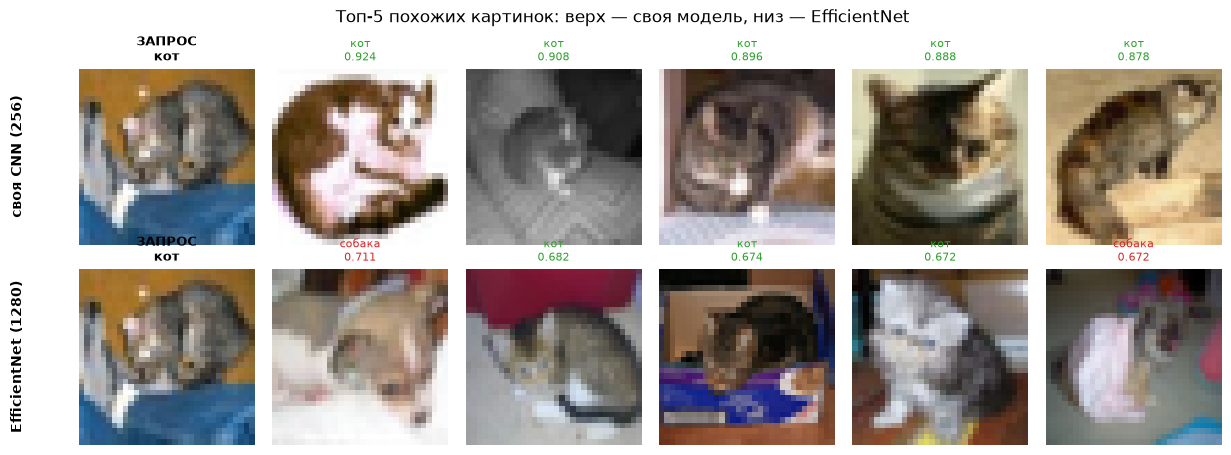

In [70]:
def show_neighbours(query_idx, k=5):
    """Рисует картинку-запрос и топ-k соседей по обеим моделям."""
    true_cls = test_set.targets[query_idx]

    results = [
        ('своя CNN (256)',    top_k_neighbours(emb_own, query_idx, k)),
        ('EfficientNet (1280)', top_k_neighbours(emb_eff, query_idx, k)),
    ]

    fig, axes = plt.subplots(2, k + 1, figsize=(2.05 * (k + 1), 4.6))
    for row, (name, (idxs, sims)) in enumerate(results):
        # первая колонка - сам запрос
        axes[row, 0].imshow(raw_test[query_idx][0])
        axes[row, 0].set_title('ЗАПРОС\n%s' % CLASSES[true_cls], fontsize=9, weight='bold')
        axes[row, 0].axis('off')
        axes[row, 0].set_ylabel(name)

        for col, (i, sim) in enumerate(zip(idxs, sims), start=1):
            cls = test_set.targets[i]
            ok = (cls == true_cls)
            axes[row, col].imshow(raw_test[i][0])
            axes[row, col].set_title('%s\n%.3f' % (CLASSES[cls], sim), fontsize=8,
                                     color='tab:green' if ok else 'tab:red')
            axes[row, col].axis('off')

        # подпись ряда слева
        axes[row, 0].text(-0.35, 0.5, name, transform=axes[row, 0].transAxes,
                          rotation=90, va='center', ha='center', fontsize=10, weight='bold')

    plt.suptitle('Топ-%d похожих картинок: верх — своя модель, низ — EfficientNet' % k)
    plt.tight_layout()
    plt.show()


show_neighbours(0)

Посмотрим ещё на нескольких запросах — разные классы ведут себя по-разному.
Поменяй индексы в списке, чтобы взять свои картинки.

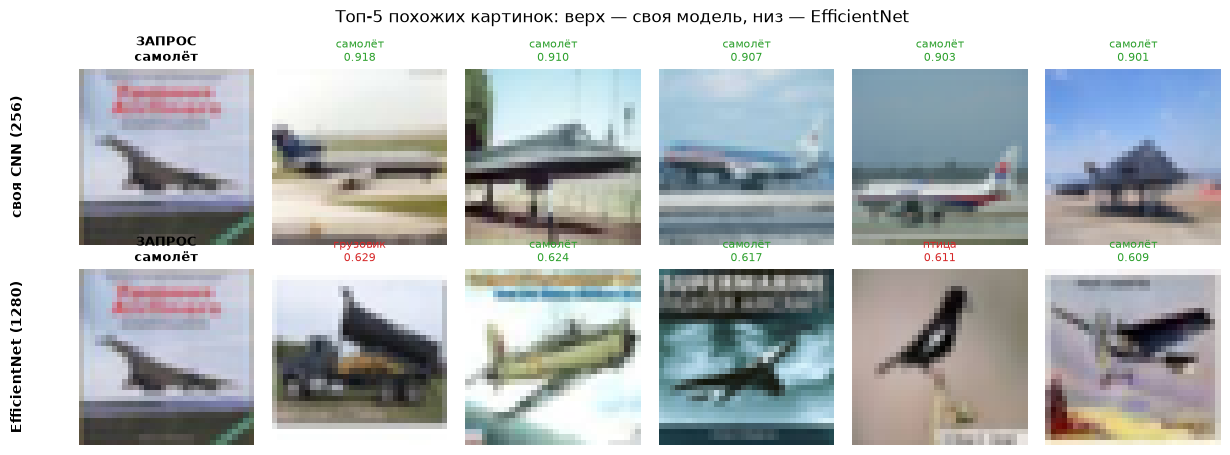

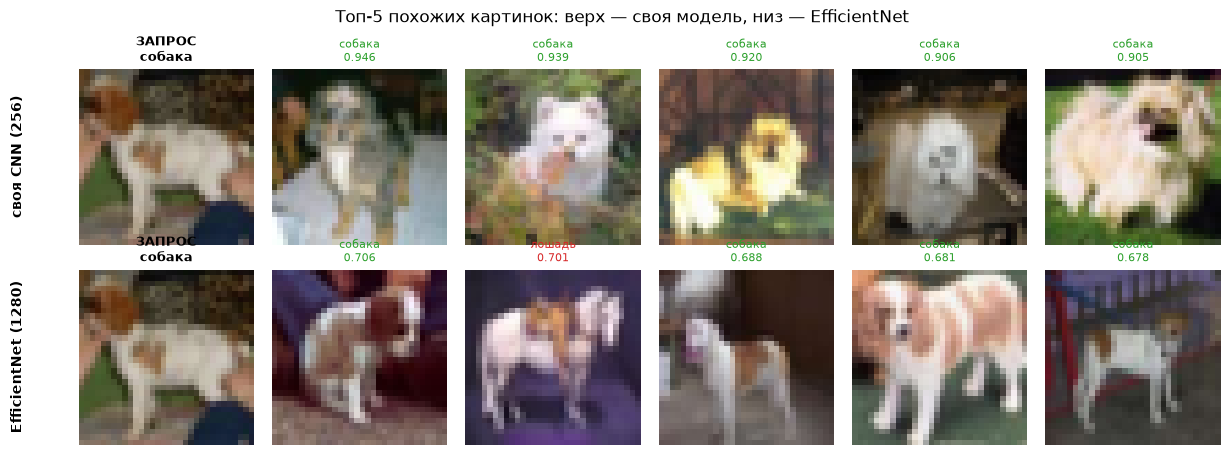

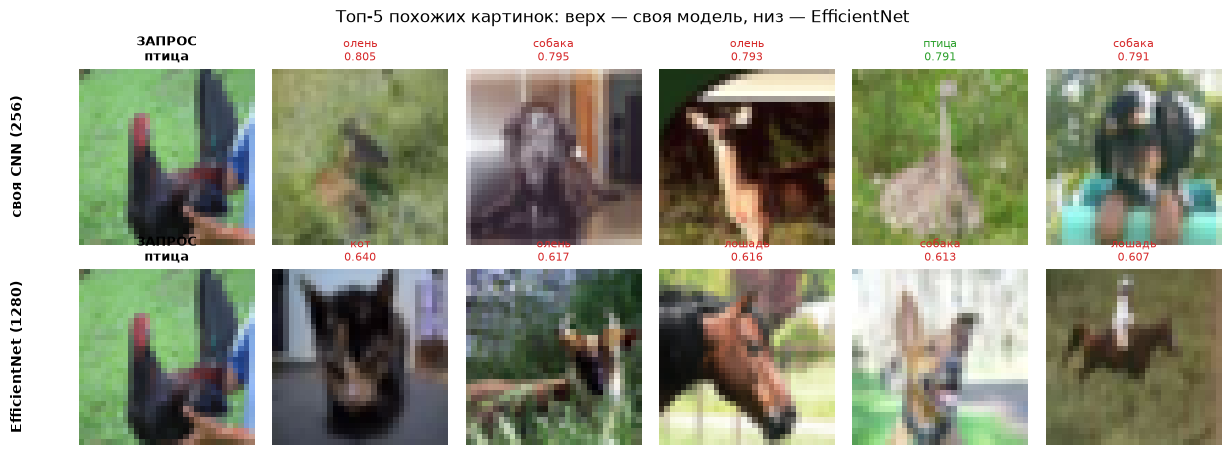

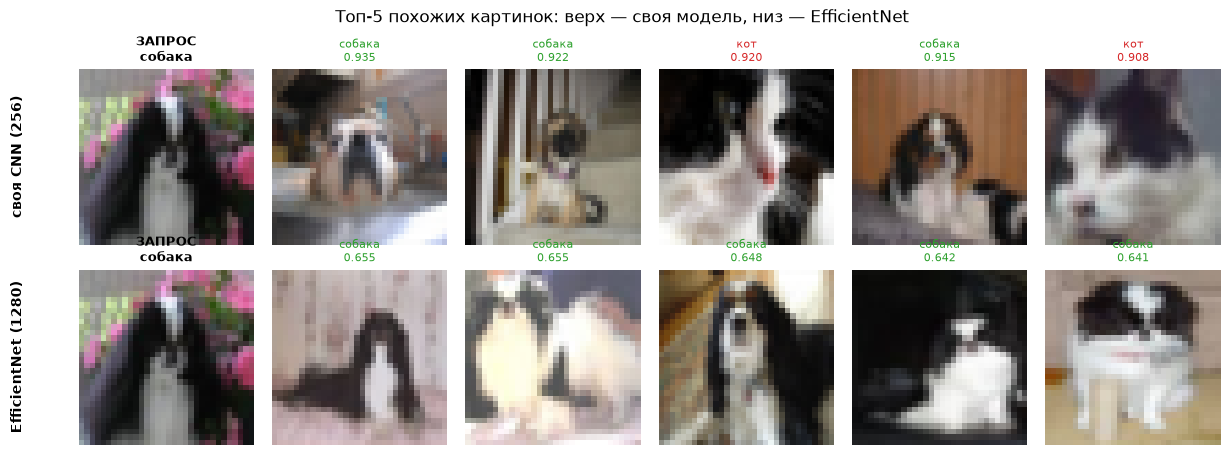

In [71]:
for q in [3, 12, 25, 42]:
    show_neighbours(q)

## 17. Считаем, кто ищет точнее

Глазами видно не всё. Посчитаем честную метрику по **всем 10 000 картинкам**:

**precision@5** — какая доля из 5 найденных соседей оказалась того же класса,
что и запрос. Если все 5 — единица, если ни одного — ноль. Усредняем по всем
запросам.

Считаем сразу для всех картинок матрицей, а не по одной — так в сотни раз
быстрее.

In [72]:
def precision_at_k(emb, labels, k=5, chunk=1000):
    """Средняя доля соседей того же класса среди k ближайших."""
    emb = F.normalize(emb, dim=1)
    labels = torch.as_tensor(labels)
    hits = []

    # считаем кусками, чтобы матрица 10000x10000 не съела всю память
    for start in range(0, len(emb), chunk):
        block = emb[start:start + chunk]
        sims = block @ emb.T                                  # (chunk, N)
        # убираем саму картинку из её же соседей
        rows = torch.arange(len(block))
        sims[rows, rows + start] = -2
        top = sims.topk(k, dim=1).indices                      # (chunk, k)
        same = (labels[top] == labels[start:start + chunk, None]).float()
        hits.append(same.mean(dim=1))

    return torch.cat(hits)


test_labels = torch.tensor(test_set.targets)

p_own  = precision_at_k(emb_own,  test_labels, k=5)
p_deep = precision_at_k(emb_deep, test_labels, k=5)
p_eff  = precision_at_k(emb_eff,  test_labels, k=5)

print('precision@5, усреднённая по всем 10 000 картинкам:')
print()
print('  мелкая CNN (256)   : %.4f  (%.1f%%)' % (p_own.mean(),  p_own.mean() * 100))
print('  глубокая CNN (512) : %.4f  (%.1f%%)' % (p_deep.mean(), p_deep.mean() * 100))
print('  EfficientNet (1280): %.4f  (%.1f%%)' % (p_eff.mean(),  p_eff.mean() * 100))
print()
print('глубина дала    : %+.1f п.п.' % ((p_deep.mean() - p_own.mean()) * 100))
print('предобучение    : %+.1f п.п. сверх глубокой' % ((p_eff.mean() - p_deep.mean()) * 100))
print('всего до EffNet : %+.1f п.п.' % ((p_eff.mean() - p_own.mean()) * 100))

precision@5, усреднённая по всем 10 000 картинкам:

  мелкая CNN (256)   : 0.8370  (83.7%)
  глубокая CNN (512) : 0.8836  (88.4%)
  EfficientNet (1280): 0.8159  (81.6%)

глубина дала    : +4.7 п.п.
предобучение    : -6.8 п.п. сверх глубокой
всего до EffNet : -2.1 п.п.


### По классам

Средняя цифра прячет детали: на каких-то классах модели работают одинаково,
а на каких-то расходятся сильно.

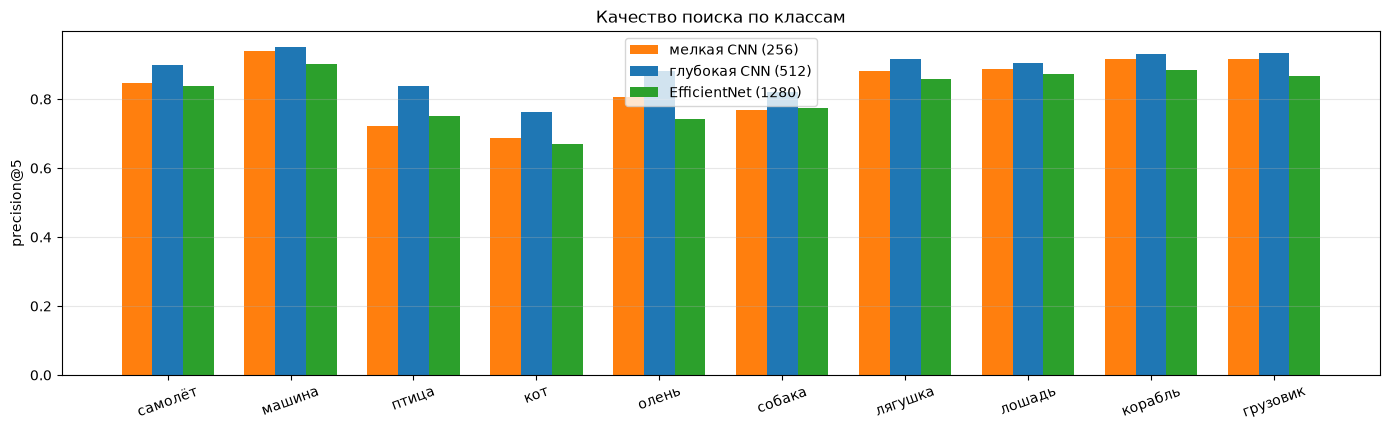

класс           мелкая   глубокая  EfficientNet глубина даёт
самолёт          0.847      0.898         0.838       +0.051
машина           0.939      0.950         0.901       +0.011
птица            0.721      0.837         0.751       +0.116  (животное)
кот              0.688      0.764         0.671       +0.075  (животное)
олень            0.806      0.883         0.743       +0.076  (животное)
собака           0.768      0.819         0.773       +0.051  (животное)
лягушка          0.881      0.917         0.857       +0.036  (животное)
лошадь           0.888      0.903         0.872       +0.015  (животное)
корабль          0.915      0.930         0.884       +0.015
грузовик         0.917      0.935         0.868       +0.018

животные: мелкая 0.792 -> глубокая 0.854 (+0.062)
техника : мелкая 0.904 -> глубокая 0.928 (+0.024)


In [73]:
per_class = np.zeros((3, 10))
for c in range(10):
    mask = test_labels == c
    per_class[0, c] = p_own[mask].mean()
    per_class[1, c] = p_deep[mask].mean()
    per_class[2, c] = p_eff[mask].mean()

x = np.arange(10)
plt.figure(figsize=(14, 4.4))
plt.bar(x - 0.25, per_class[0], 0.25, label='мелкая CNN (256)',    color='tab:orange')
plt.bar(x,        per_class[1], 0.25, label='глубокая CNN (512)',  color='tab:blue')
plt.bar(x + 0.25, per_class[2], 0.25, label='EfficientNet (1280)', color='tab:green')
plt.xticks(x, CLASSES, rotation=20)
plt.ylabel('precision@5')
plt.title('Качество поиска по классам')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('%-12s %9s %10s %13s %12s' % ('класс', 'мелкая', 'глубокая', 'EfficientNet', 'глубина даёт'))
for c in range(10):
    print('%-12s %9.3f %10.3f %13.3f %+12.3f%s' %
          (CLASSES[c], per_class[0, c], per_class[1, c], per_class[2, c],
           per_class[1, c] - per_class[0, c], '  (животное)' if ANIMALS[c] else ''))

print()
print('животные: мелкая %.3f -> глубокая %.3f (%+.3f)' %
      (per_class[0][ANIMALS].mean(), per_class[1][ANIMALS].mean(),
       per_class[1][ANIMALS].mean() - per_class[0][ANIMALS].mean()))
print('техника : мелкая %.3f -> глубокая %.3f (%+.3f)' %
      (per_class[0][~ANIMALS].mean(), per_class[1][~ANIMALS].mean(),
       per_class[1][~ANIMALS].mean() - per_class[0][~ANIMALS].mean()))

## 18. Карта эмбеддингов

Свернём векторы в две координаты через **t-SNE** и посмотрим на всё
пространство разом. t-SNE старается сохранить соседство: то, что было рядом
в 256 или 1280 измерениях, останется рядом и на плоскости.

Чем плотнее и отдельнее кучки одного цвета — тем лучше устроены эмбеддинги.
Берём 2000 картинок, на всех 10 000 t-SNE считался бы очень долго.

мелкая CNN (256): t-SNE за 4.2 сек
глубокая CNN (512): t-SNE за 3.5 сек
EfficientNet (1280): t-SNE за 4.6 сек


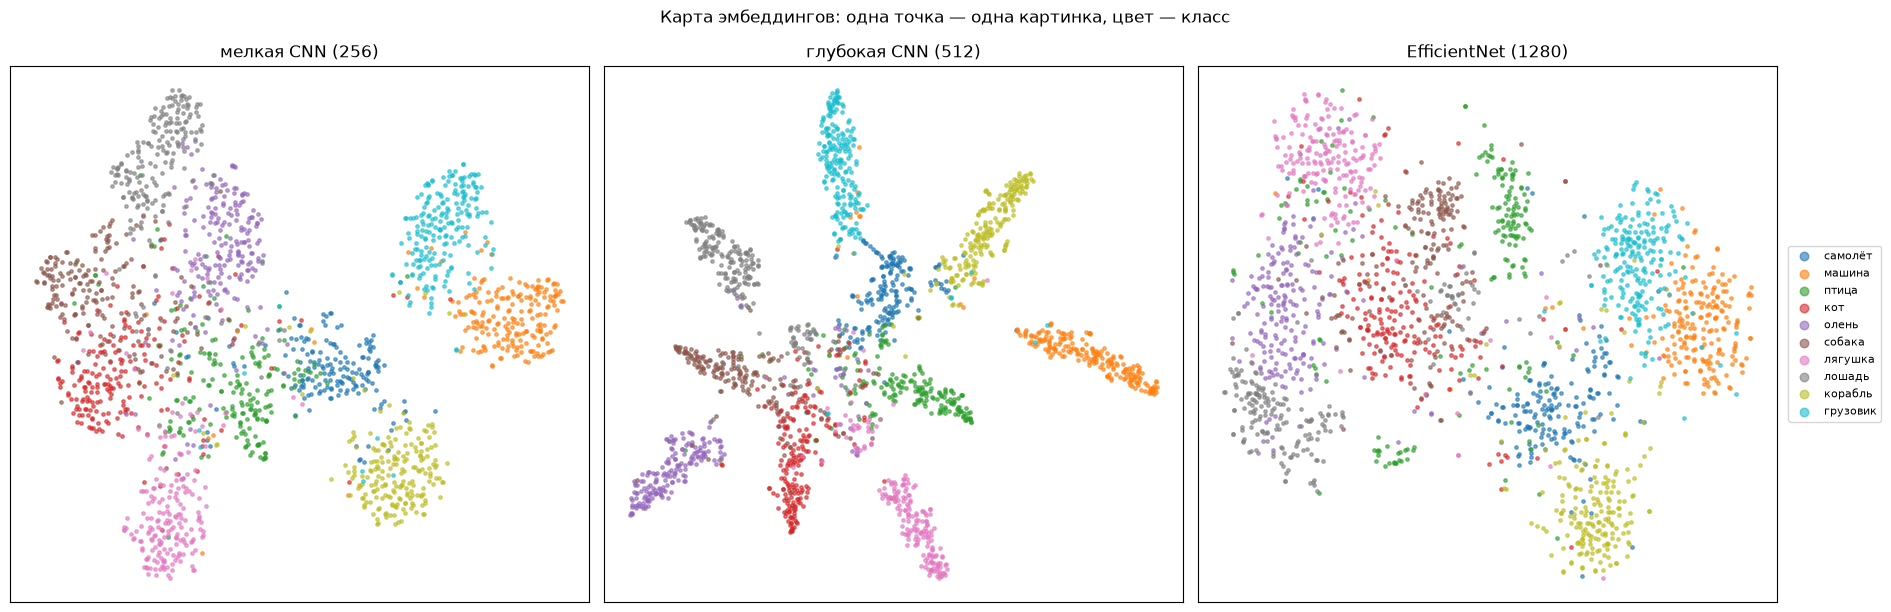

In [74]:
from sklearn.manifold import TSNE

N_VIS = 2000
sub = np.random.RandomState(SEED).choice(len(test_set), N_VIS, replace=False)
sub_labels = test_labels[sub].numpy()

fig, axes = plt.subplots(1, 3, figsize=(19, 6.2))
for ax, (name, emb) in zip(axes, [('мелкая CNN (256)', emb_own),
                                  ('глубокая CNN (512)', emb_deep),
                                  ('EfficientNet (1280)', emb_eff)]):
    t = time.time()
    xy = TSNE(n_components=2, init='pca', perplexity=30,
              random_state=SEED).fit_transform(emb[sub].numpy())
    print('%s: t-SNE за %.1f сек' % (name, time.time() - t))

    for c in range(10):
        m = sub_labels == c
        ax.scatter(xy[m, 0], xy[m, 1], s=6, alpha=0.6, label=CLASSES[c])
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])

axes[2].legend(markerscale=2.5, fontsize=8, loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.suptitle('Карта эмбеддингов: одна точка — одна картинка, цвет — класс')
plt.tight_layout()
plt.show()

## 19. Диагностика: с чем именно путаются классы

Средняя precision@5 говорит «класс плохой», но не говорит **почему**.
Прежде чем что-то чинить, надо увидеть, **с кем** класс путается.

Строим матрицу: строка — класс запроса, столбец — класс найденного соседа.
Диагональ — правильные попадания, всё остальное — путаница.

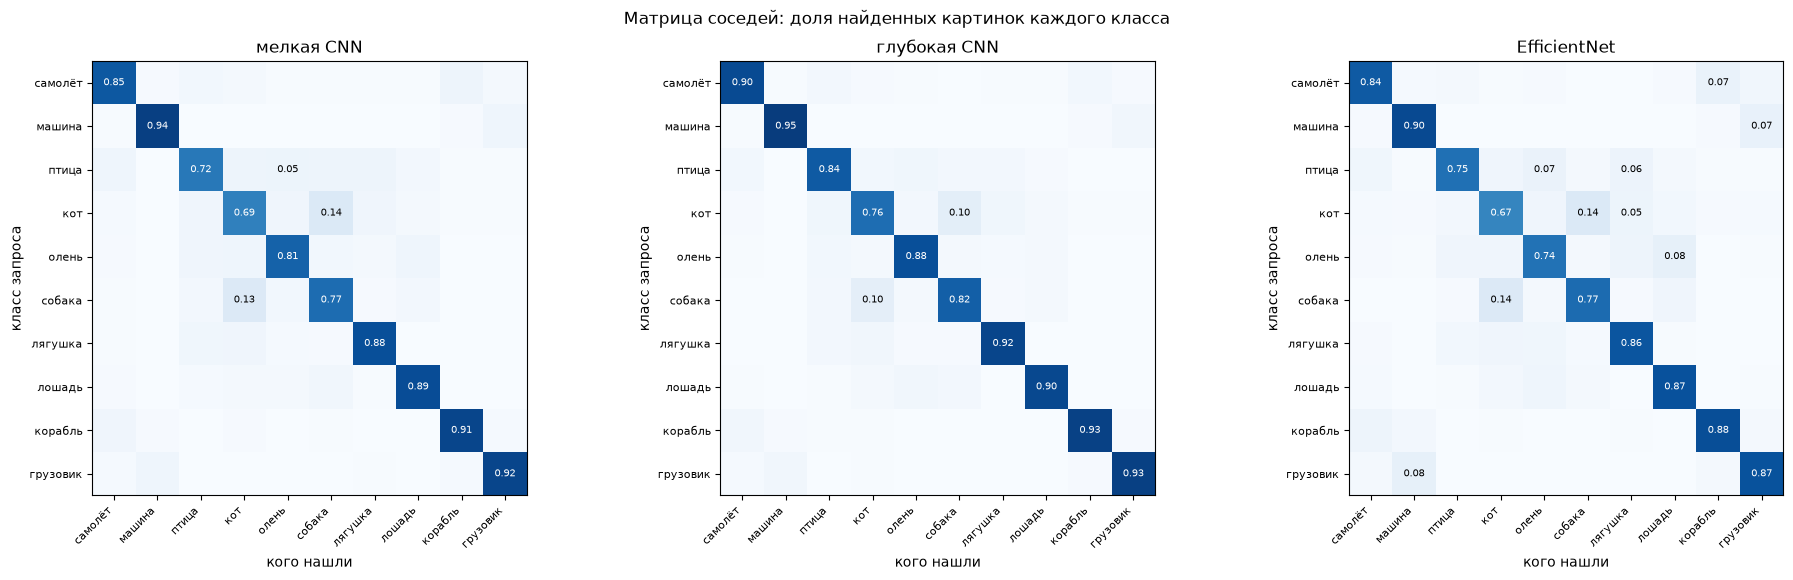

In [75]:
def neighbour_confusion(emb, labels, k=5, chunk=1000):
    """Матрица 10x10: кого находит каждый класс в своих k соседях."""
    emb = F.normalize(emb, dim=1)
    labels = torch.as_tensor(labels)
    conf = np.zeros((10, 10))

    for start in range(0, len(emb), chunk):
        block = emb[start:start + chunk]
        sims = block @ emb.T
        rows = torch.arange(len(block))
        sims[rows, rows + start] = -2
        top = sims.topk(k, dim=1).indices
        for q, neigh in zip(labels[start:start + chunk], labels[top]):
            for n in neigh:
                conf[q, n] += 1

    return conf / conf.sum(axis=1, keepdims=True)      # доли по строке


conf_own  = neighbour_confusion(emb_own,  test_labels)
conf_deep = neighbour_confusion(emb_deep, test_labels)
conf_eff  = neighbour_confusion(emb_eff,  test_labels)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))
for ax, (name, conf) in zip(axes, [('мелкая CNN', conf_own),
                                   ('глубокая CNN', conf_deep),
                                   ('EfficientNet', conf_eff)]):
    im = ax.imshow(conf, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel('кого нашли'); ax.set_ylabel('класс запроса')
    ax.set_title(name)
    for i in range(10):
        for j in range(10):
            if conf[i, j] >= 0.05:
                ax.text(j, i, '%.2f' % conf[i, j], ha='center', va='center',
                        fontsize=7, color='white' if conf[i, j] > 0.5 else 'black')

plt.suptitle('Матрица соседей: доля найденных картинок каждого класса')
plt.tight_layout()
plt.show()

### Главные пары-путаницы

Выпишем топ-10 пар, которые путаются сильнее всего. Это и есть список того,
над чем стоит работать.

In [76]:
pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            pairs.append((conf_own[i, j], CLASSES[i], CLASSES[j]))
pairs.sort(reverse=True)

print('Своя CNN — с кем путается каждый класс (топ-10 пар):')
print('%-12s -> %-12s %8s' % ('запрос', 'находит', 'доля'))
for v, a, b in pairs[:10]:
    print('%-12s -> %-12s %8.3f' % (a, b, v))

print()
print('Для сравнения, те же пары у EfficientNet:')
for v, a, b in pairs[:10]:
    i, j = CLASSES.index(a), CLASSES.index(b)
    print('%-12s -> %-12s %8.3f  (было %.3f)' % (a, b, conf_eff[i, j], v))

Своя CNN — с кем путается каждый класс (топ-10 пар):
запрос       -> находит          доля
кот          -> собака          0.139
собака       -> кот             0.134
птица        -> олень           0.055
птица        -> кот             0.049
самолёт      -> корабль         0.048
птица        -> лягушка         0.048
птица        -> собака          0.047
олень        -> кот             0.046
птица        -> самолёт         0.045
олень        -> лошадь          0.045

Для сравнения, те же пары у EfficientNet:
кот          -> собака          0.138  (было 0.139)
собака       -> кот             0.135  (было 0.134)
птица        -> олень           0.066  (было 0.055)
птица        -> кот             0.041  (было 0.049)
самолёт      -> корабль         0.067  (было 0.048)
птица        -> лягушка         0.058  (было 0.048)
птица        -> собака          0.016  (было 0.047)
олень        -> кот             0.041  (было 0.046)
птица        -> самолёт         0.036  (было 0.045)
олень        -> ло

### Смотрим на конкретные промахи

Возьмём класс, который тебя беспокоит, и посмотрим на его худшие запросы —
те, где ни один из 5 соседей не оказался правильным.

Худшие запросы класса «собака» (precision@5 = 0.77):


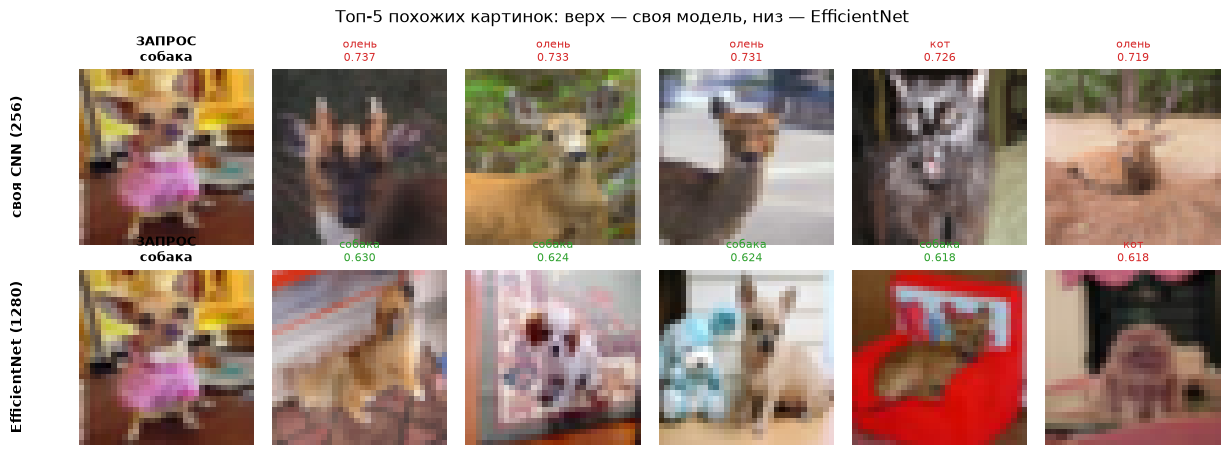

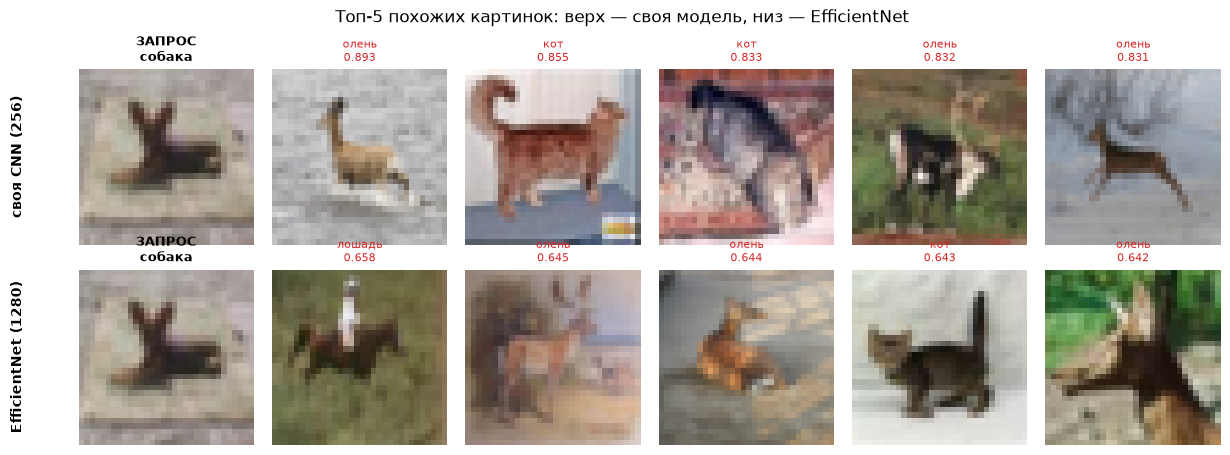

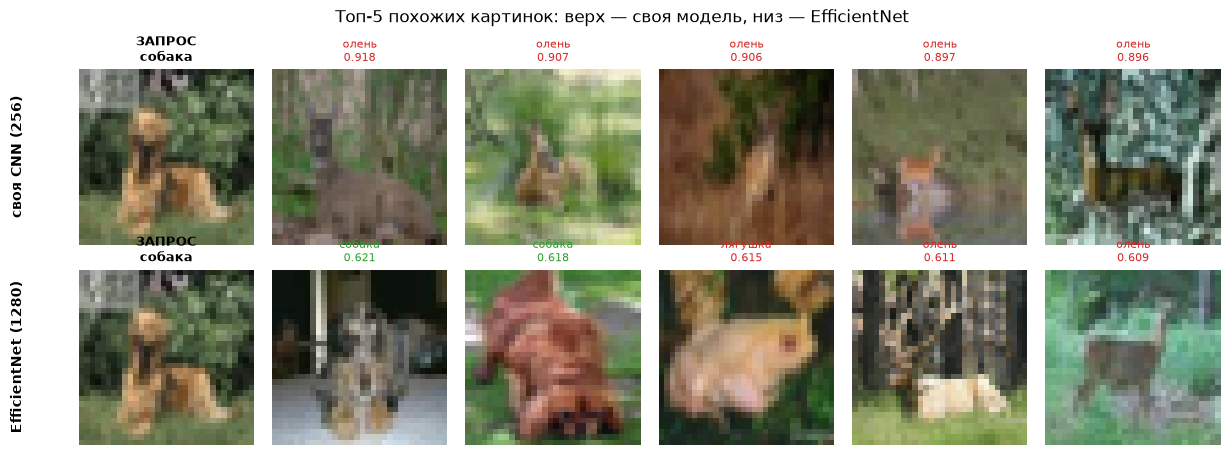

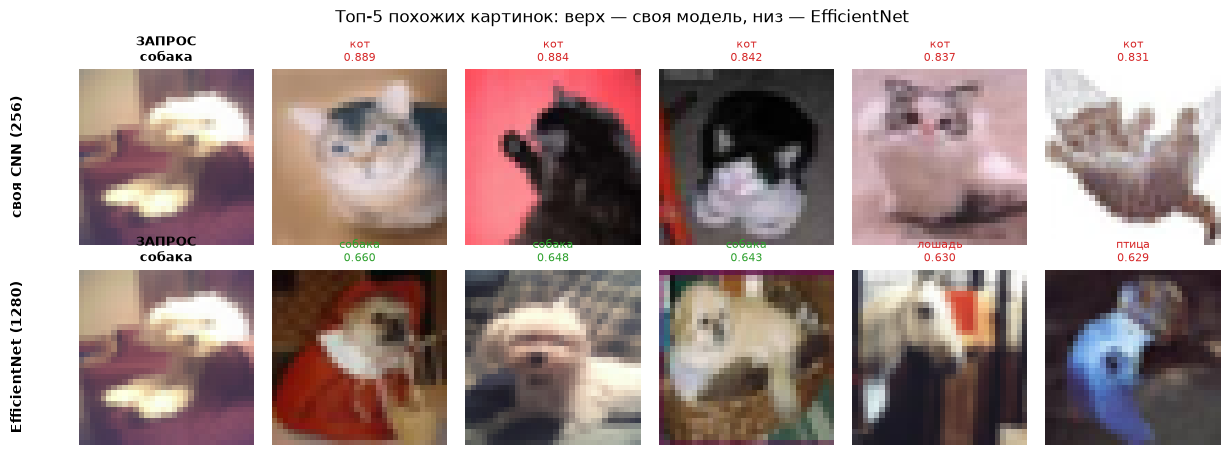

In [77]:
PROBLEM_CLASS = 'собака'          # поменяй на свой проблемный класс

cls_id = CLASSES.index(PROBLEM_CLASS)
mask = (test_labels == cls_id).numpy()
scores = p_own.numpy().copy()
scores[~mask] = 99                               # интересуют только нужный класс
worst = np.argsort(scores)[:4]                   # 4 самых провальных запроса

print('Худшие запросы класса «%s» (precision@5 = %.2f):' %
      (PROBLEM_CLASS, p_own[mask].mean()))
for q in worst:
    show_neighbours(int(q))

## 20. Что делать с проблемными классами

Разобравшись, **с кем** путается класс, можно выбрать лечение. Причины бывают
разные, и лечатся они по-разному — универсального ответа нет.

**Случай 1: путаются два похожих класса (кот↔собака, лошадь↔олень).**
Это не баг, а честная сложность: на картинке 32x32 у них правда мало отличий.
Что помогает:
- более сильная сеть или больше эпох — тонкие признаки требуют ёмкости
- эмбеддинги от предобученной сети (ты это уже видишь: собака 0.475 -> 0.773)
- обучение с metric learning (triplet loss) — сеть учат **раздвигать** похожие классы

**Случай 2: класс путается со всем подряд.**
Признак недообучения. Помогает просто больше эпох и проверка, что loss ещё падает.

**Случай 3: сеть цепляется за фон, а не за объект.**
Лошади и олени часто на траве, корабли на воде. Проверяется тем, что путаница
идёт по «сценам», а не по формам. Помогает более агрессивный `RandomResizedCrop`
(объект попадает в кадр по-разному) и `RandomErasing`.

**Чего делать НЕ надо:** выбрасывать проблемный класс, подгонять аугментацию
под тест или оценивать качество на train — всё это улучшит цифру, но не модель.

In [78]:
# Быстрая проверка: стало ли лучше от предобученных эмбеддингов
print('%-12s %10s %14s %10s' % ('класс', 'мелкая CNN', 'EfficientNet', 'выигрыш'))
order = np.argsort(per_class[2] - per_class[0])[::-1]
for c in order:
    gain = per_class[2, c] - per_class[0, c]
    flag = '  <- сильнее всего выигрывает' if gain == (per_class[2] - per_class[0]).max() else ''
    print('%-12s %10.3f %14.3f %+10.3f%s' %
          (CLASSES[c], per_class[0, c], per_class[2, c], gain, flag))

print()
print('Вывод: чем хуже класс работал на своей сети, тем больше он выигрывает')
print('от предобученных признаков — именно «сложным» классам не хватало ёмкости.')

класс        мелкая CNN   EfficientNet    выигрыш
птица             0.721          0.751     +0.030  <- сильнее всего выигрывает
собака            0.768          0.773     +0.004
самолёт           0.847          0.838     -0.008
лошадь            0.888          0.872     -0.016
кот               0.688          0.671     -0.018
лягушка           0.881          0.857     -0.023
корабль           0.915          0.884     -0.030
машина            0.939          0.901     -0.038
грузовик          0.917          0.868     -0.049
олень             0.806          0.743     -0.064

Вывод: чем хуже класс работал на своей сети, тем больше он выигрывает
от предобученных признаков — именно «сложным» классам не хватало ёмкости.


## 21. Выводы по эмбеддингам

- **Эмбеддинг — это описание картинки числами.** Похожие картинки дают близкие
  векторы, поэтому поиск похожих сводится к расстоянию между векторами.
  Классификатор для этого не нужен.
- **EfficientNet ищет лучше, хотя CIFAR-10 в глаза не видел.** Он обучался на
  ImageNet — в 24 раза большем наборе — и выучил универсальные признаки,
  которые переносятся на чужие данные. Это и есть transfer learning.
- **Наша сеть проигрывает не потому, что плохая**, а потому, что видела мало
  данных и мелкие картинки 32x32. Её эмбеддинги заточены ровно под 10 классов
  CIFAR-10 и за их пределами бесполезны.
- Ошибки обеих моделей осмысленные: путаются кот/собака, машина/грузовик,
  олень/лошадь — классы, которые и человек на картинке 32x32 различает с трудом.

**Что попробовать:**
- дообучить EfficientNet на CIFAR-10 (разморозить последние слои) — будет
  лучше обоих вариантов
- взять `efficientnet_b3` вместо `b0` — вектор больше, качество выше, считает дольше
- попробовать метрику L2 вместо косинусной и сравнить результат